In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from tqdm import tqdm


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
data = pd.read_excel('data.xlsx')

In [ ]:
data.head(2)

,category,caterory_url,product_name,product_url,advantages,disadvantages,comments,Label
0,Ноутбуки,https://www.citilink.ru/catalog/noutbuki/?ref=...,"Ноутбук Huawei MateBook D 16 16"", 2023, IPS, I...",https://www.citilink.ru/product/noutbuk-huawei...,Оптимальное сочетание современных характеристи...,Небольшие трудности при установке ОС,Про трудности при установке Windows многие уже...,0
1,Ноутбуки,https://www.citilink.ru/catalog/noutbuki/?ref=...,"Ноутбук Huawei MateBook D 16 16"", 2023, IPS, I...",https://www.citilink.ru/product/noutbuk-huawei...,"Ноутбук достойный, работает шустро - мой стары...","Пишут про малое количество ЮСБ-портов, наверно...",Приобрел ноут SSD 1 Тб с ОЗУ 16 Гб примерно ме...,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21810 entries, 0 to 21809
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   category       21810 non-null  object
 1   caterory_url   21810 non-null  object
 2   product_name   21810 non-null  object
 3   product_url    21810 non-null  object
 4   advantages     17673 non-null  object
 5   disadvantages  15884 non-null  object
 6   comments       21178 non-null  object
 7   Label          21810 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 1.3+ MB


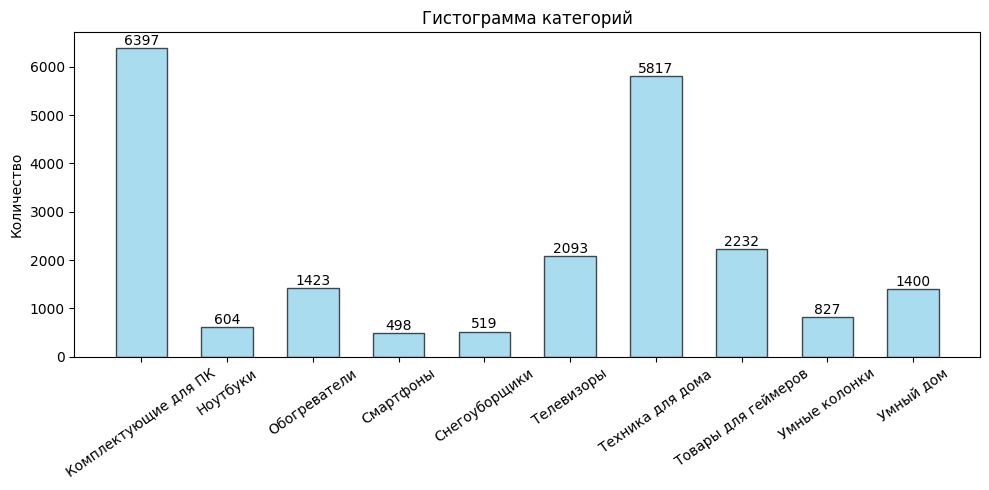

In [ ]:
value_counts = data['category'].value_counts().sort_index()

fig = plt.figure(figsize=(10, 5))

bars = plt.bar(
    value_counts.index,
    value_counts.values,
    width=0.6,
    edgecolor='black',
    alpha=0.7,
    color='skyblue'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=35)
plt.ylabel('Количество')
plt.title('Гистограмма категорий')

plt.tight_layout()
plt.show()

In [ ]:
df = data[[not elem for elem in data.comments.isna()]].reset_index()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21178 entries, 0 to 21177
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   index          21178 non-null  int64 
 1   category       21178 non-null  object
 2   caterory_url   21178 non-null  object
 3   product_name   21178 non-null  object
 4   product_url    21178 non-null  object
 5   advantages     17340 non-null  object
 6   disadvantages  15603 non-null  object
 7   comments       21178 non-null  object
 8   Label          21178 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 1.5+ MB


In [ ]:
texts = df.comments.values.tolist()
labels = df.Label.values

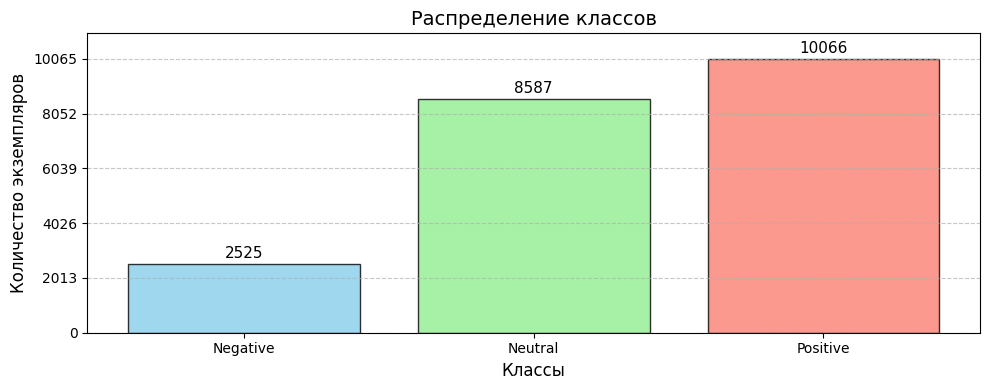

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 4))
counts, bins, patches = plt.hist(labels, bins=[-0.5, 0.5, 1.5, 2.5],
                                 edgecolor='black', alpha=0.8, rwidth=0.8)

colors = ['skyblue', 'lightgreen', 'salmon']
for i, patch in enumerate(patches):
    patch.set_facecolor(colors[i])

plt.xticks([0, 1, 2], ['Negative', 'Neutral', 'Positive'])
plt.yticks(np.arange(0, max(counts)+1, max(counts)//5))

plt.title('Распределение классов', fontsize=14)
plt.xlabel('Классы', fontsize=12)
plt.ylabel('Количество экземпляров', fontsize=12)

for i, count in enumerate(counts):
    plt.text(i, count + max(counts)*0.01, str(int(count)),
             ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.ylim((0,11000))
plt.show()


# LogReg

## LogReg + bag of words

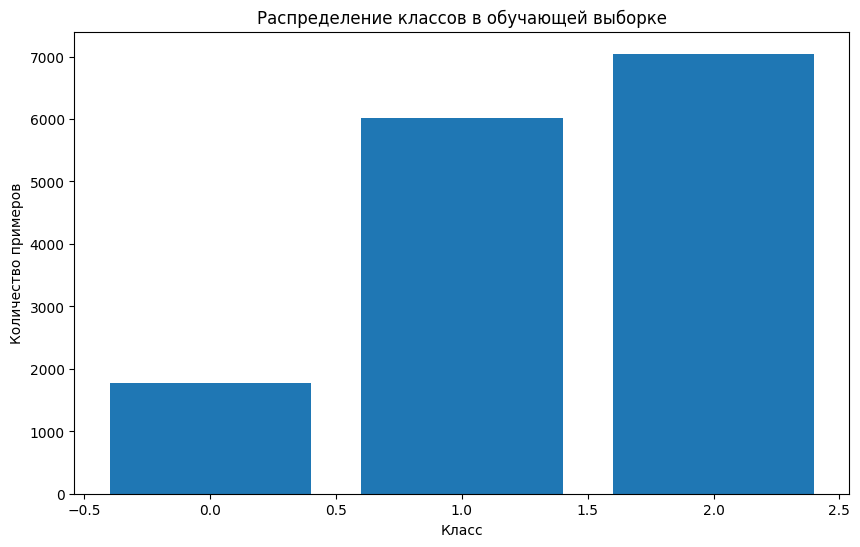

Веса классов: {0: np.float64(2.7964534993397474), 1: np.float64(0.822048466699939), 2: np.float64(0.7012962437316681)}


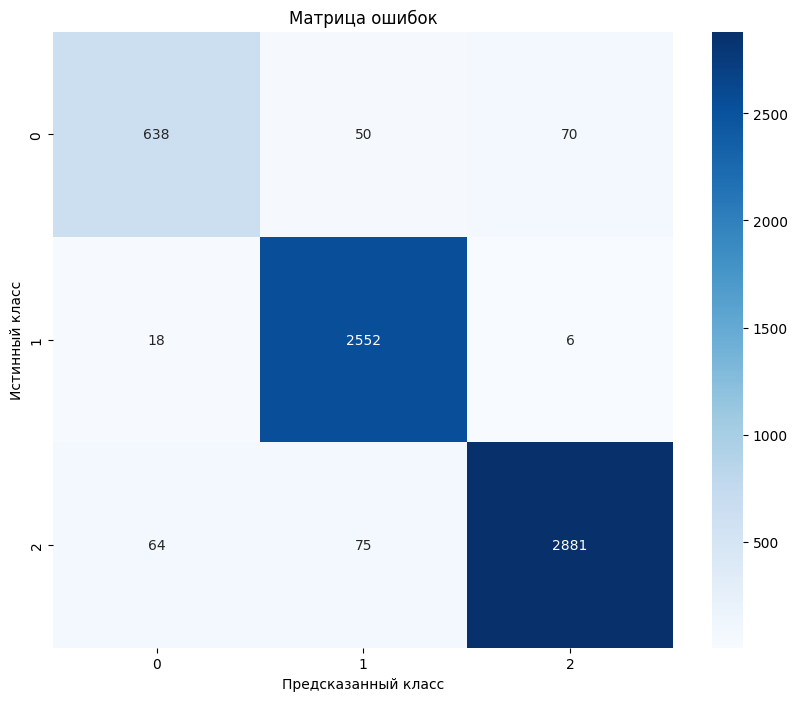

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
import seaborn as sns

def compute_class_weight(y):
    class_counts = np.bincount(y)
    total_samples = len(y)
    weights = total_samples / (len(class_counts) * class_counts)
    weight_dict = {i: weight for i, weight in enumerate(weights)}
    return weight_dict


X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.3, random_state=42, stratify=labels
)

plt.figure(figsize=(10, 6))
class_dist = np.bincount(y_train)
plt.bar(range(len(class_dist)), class_dist)
plt.xlabel('Класс')
plt.ylabel('Количество примеров')
plt.title('Распределение классов в обучающей выборке')
plt.show()

class_weights = compute_class_weight(y_train)
print("Веса классов:", class_weights)

pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', LogisticRegression(
        penalty='l2' # l1, elasticnet
        max_iter=1000, # 100 500 2000
        multi_class='multinomial',
        solver='sag', # saga, lbfgs
        class_weight=class_weights,
        С = 1.0 # 0.1, 0.5, 5.0,


    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

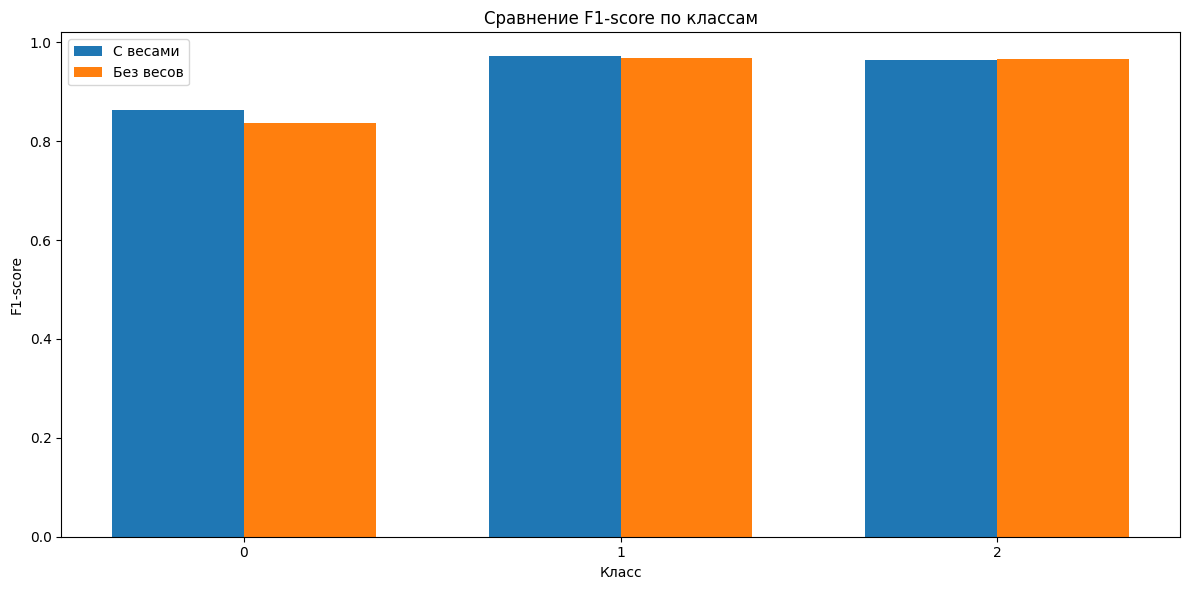

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
import seaborn as sns

def compute_class_weight(y):
    class_counts = np.bincount(y)
    total_samples = len(y)
    weights = total_samples / (len(class_counts) * class_counts)
    weight_dict = {i: weight for i, weight in enumerate(weights)}
    return weight_dict

pipeline_no_weights = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', LogisticRegression(
        max_iter=1000,
        multi_class='multinomial',
        solver='lbfgs'
    ))
])

pipeline_no_weights.fit(X_train, y_train)
y_pred_no_weights = pipeline_no_weights.predict(X_test)


report_weighted = classification_report(y_test, y_pred, output_dict=True)
report_no_weights = classification_report(y_test, y_pred_no_weights, output_dict=True)

classes = sorted(list(set(labels)))
comparison_data = []

for cls in classes:
    cls_str = str(cls)
    if cls_str in report_weighted:
        comparison_data.append({
            'Класс': cls,
            'Частота': class_dist[cls] if cls < len(class_dist) else 0,
            'F1 с весами': report_weighted[cls_str]['f1-score'],
            'F1 без весов': report_no_weights[cls_str]['f1-score']
        })

comparison_data.append({
    'Класс': 'macro avg',
    'Частота': np.nan,
    'F1 с весами': report_weighted['macro avg']['f1-score'],
    'F1 без весов': report_no_weights['macro avg']['f1-score']
})

comparison_df = pd.DataFrame(comparison_data)

plt.figure(figsize=(12, 6))
bar_width = 0.35
x = np.arange(len(classes))

weighted_f1 = [comparison_data[i]['F1 с весами'] for i in range(len(classes))]
no_weights_f1 = [comparison_data[i]['F1 без весов'] for i in range(len(classes))]

plt.bar(x - bar_width/2, weighted_f1, bar_width, label='С весами')
plt.bar(x + bar_width/2, no_weights_f1, bar_width, label='Без весов')

plt.xlabel('Класс')
plt.ylabel('F1-score')
plt.title('Сравнение F1-score по классам')
plt.xticks(x, classes)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

pipeline_weighted = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', LogisticRegression(
        max_iter=1000,
        multi_class='multinomial',
        solver='lbfgs',
        class_weight=class_weight_dict
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

cv_results = cross_validate(
    pipeline_weighted,
    texts,
    labels,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)

results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Macro', 'Precision Macro', 'Recall Macro'],
    'Mean': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1_macro'].mean(),
        cv_results['test_precision_macro'].mean(),
        cv_results['test_recall_macro'].mean()
    ],
    'Std': [
        cv_results['test_accuracy'].std(),
        cv_results['test_f1_macro'].std(),
        cv_results['test_precision_macro'].std(),
        cv_results['test_recall_macro'].std()
    ]
})

results_df


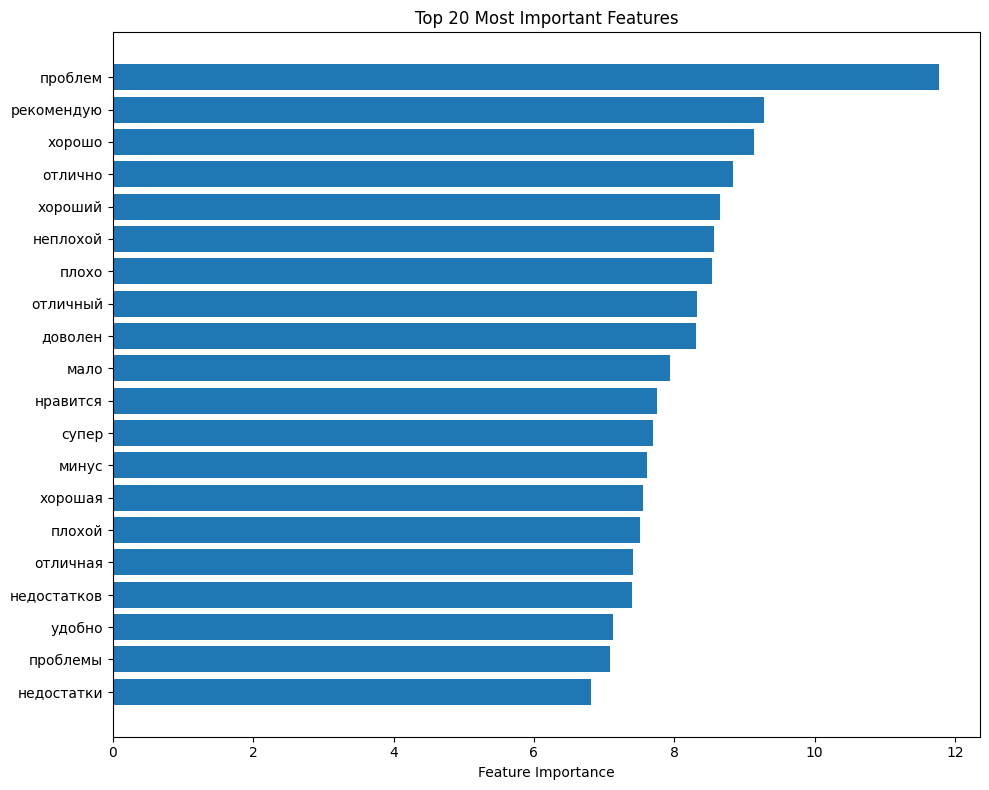

In [ ]:
if hasattr(pipeline['classifier'], 'coef_'):
    feature_names = pipeline['vectorizer'].get_feature_names_out()

    coefficients = pipeline['classifier'].coef_

    if len(coefficients.shape) > 1 and coefficients.shape[0] > 1:
        importance = np.sum(np.abs(coefficients), axis=0)
    else:
        importance = np.abs(coefficients.ravel())

    top_n = 20
    indices = np.argsort(importance)[-top_n:]

    plt.figure(figsize=(10, 8))
    plt.barh(range(top_n), importance[indices])
    plt.yticks(range(top_n), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance')
    plt.title(f'Top {top_n} Most Important Features')
    plt.tight_layout()
    plt.show()

## LogReg + tf idf

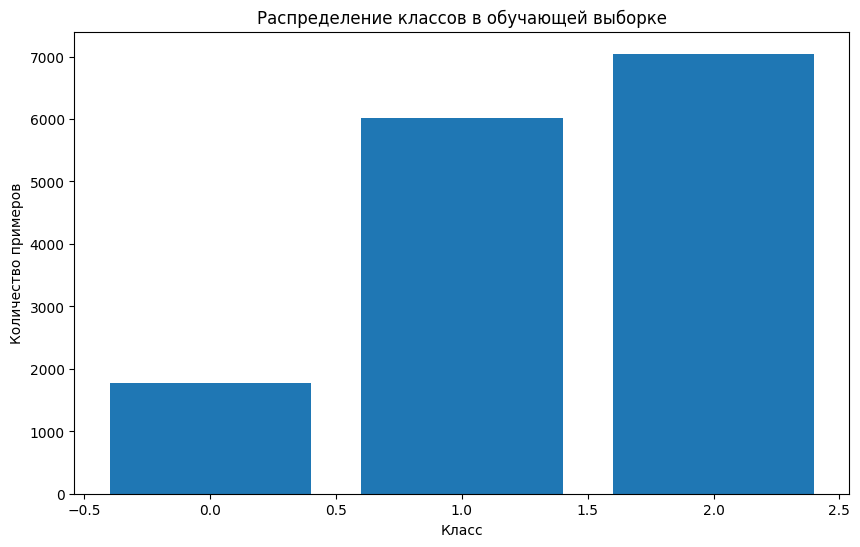

Веса классов: {0: np.float64(2.7964534993397474), 1: np.float64(0.822048466699939), 2: np.float64(0.7012962437316681)}


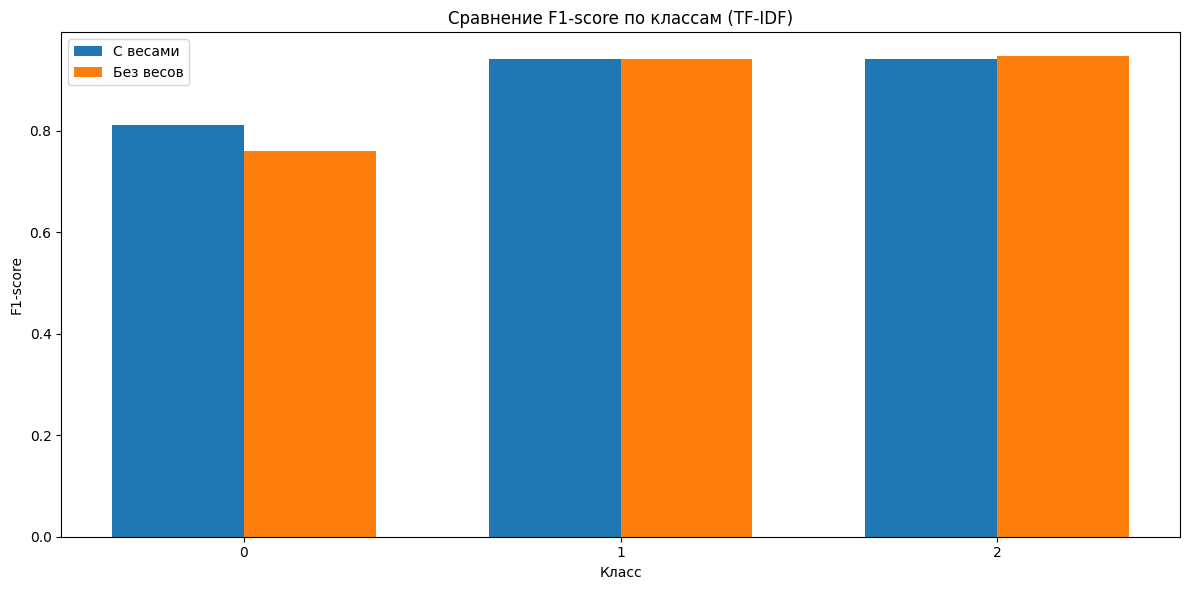


Топ-10 наиболее важных признаков для каждого класса:

Класс 0:
  1. проблем: 13.1314
  2. неплохой: 7.1971
  3. мало: 7.0642
  4. минус: 6.9364
  5. плохо: 6.6117
  6. проблемы: 6.4566
  7. проблема: 6.3762
  8. неплохо: 5.7866
  9. без проблем: 5.5686
  10. недостатки: 5.3352

Класс 1:
  1. норм: 1.5487
  2. нормальный: 1.4756
  3. советую: 1.2998
  4. устраивает: 1.1982
  5. довольны: 1.0056
  6. лучшая: 0.9787
  7. берите: 0.9640
  8. топ: 0.9382
  9. пойдет: 0.9144
  10. очень довольны: 0.9080

Класс 2:
  1. рекомендую: 7.7507
  2. хорошо: 7.4989
  3. хороший: 7.4142
  4. отличный: 7.3985
  5. отлично: 6.5516
  6. доволен: 6.2045
  7. хорошая: 5.3853
  8. отличная: 5.0542
  9. супер: 4.8429
  10. удобно: 4.6342


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
import seaborn as sns

def compute_class_weight(y):
    class_counts = np.bincount(y)
    total_samples = len(y)
    weights = total_samples / (len(class_counts) * class_counts)
    weight_dict = {i: weight for i, weight in enumerate(weights)}
    return weight_dict


X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.3, random_state=42, stratify=labels
)

plt.figure(figsize=(10, 6))
class_dist = np.bincount(y_train)
plt.bar(range(len(class_dist)), class_dist)
plt.xlabel('Класс')
plt.ylabel('Количество примеров')
plt.title('Распределение классов в обучающей выборке')
plt.show()

class_weights = compute_class_weight(y_train)
print("Веса классов:", class_weights)

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=10000)),
    ('classifier', LogisticRegression(
        max_iter=1000,
        multi_class='multinomial',
        solver='lbfgs',
        class_weight=class_weights
    ))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

pipeline_no_weights = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        use_idf=True,
        smooth_idf=True,
        sublinear_tf=True
    )),
    ('classifier', LogisticRegression(
        max_iter=1000,
        multi_class='multinomial',
        solver='lbfgs'
    ))
])

pipeline_no_weights.fit(X_train, y_train)
y_pred_no_weights = pipeline_no_weights.predict(X_test)

report_weighted = classification_report(y_test, y_pred, output_dict=True)
report_no_weights = classification_report(y_test, y_pred_no_weights, output_dict=True)

classes = sorted(list(set(labels)))
comparison_data = []

for cls in classes:
    cls_str = str(cls)
    if cls_str in report_weighted:
        comparison_data.append({
            'Класс': cls,
            'Частота': class_dist[cls] if cls < len(class_dist) else 0,
            'F1 с весами': report_weighted[cls_str]['f1-score'],
            'F1 без весов': report_no_weights[cls_str]['f1-score']
        })

comparison_data.append({
    'Класс': 'macro avg',
    'Частота': np.nan,
    'F1 с весами': report_weighted['macro avg']['f1-score'],
    'F1 без весов': report_no_weights['macro avg']['f1-score']
})

comparison_df = pd.DataFrame(comparison_data)

plt.figure(figsize=(12, 6))
bar_width = 0.35
x = np.arange(len(classes))

weighted_f1 = [comparison_data[i]['F1 с весами'] for i in range(len(classes))]
no_weights_f1 = [comparison_data[i]['F1 без весов'] for i in range(len(classes))]

plt.bar(x - bar_width/2, weighted_f1, bar_width, label='С весами')
plt.bar(x + bar_width/2, no_weights_f1, bar_width, label='Без весов')

plt.xlabel('Класс')
plt.ylabel('F1-score')
plt.title('Сравнение F1-score по классам (TF-IDF)')
plt.xticks(x, classes)
plt.legend()
plt.tight_layout()
plt.show()

if hasattr(pipeline.named_steps['classifier'], 'coef_'):
    feature_names = pipeline.named_steps['vectorizer'].get_feature_names_out()
    coefficients = pipeline.named_steps['classifier'].coef_

    print("\nТоп-10 наиболее важных признаков для каждого класса:")
    for i, cls in enumerate(classes):
        top_indices = np.argsort(coefficients[i])[-10:][::-1]
        top_features = [feature_names[idx] for idx in top_indices]
        print(f"\nКласс {cls}:")
        for j, feature in enumerate(top_features, 1):
            print(f"  {j}. {feature}: {coefficients[i][top_indices[j-1]]:.4f}")


In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

pipeline_weighted = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', LogisticRegression(
        max_iter=1000,
        multi_class='multinomial',
        solver='lbfgs',
        class_weight=class_weight_dict
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

cv_results = cross_validate(
    pipeline_weighted,
    texts,
    labels,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)

results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Macro', 'Precision Macro', 'Recall Macro'],
    'Mean': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1_macro'].mean(),
        cv_results['test_precision_macro'].mean(),
        cv_results['test_recall_macro'].mean()
    ],
    'Std': [
        cv_results['test_accuracy'].std(),
        cv_results['test_f1_macro'].std(),
        cv_results['test_precision_macro'].std(),
        cv_results['test_recall_macro'].std()
    ]
})

results_df


# CatBoost

## BoW

In [ ]:
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier

pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', CatBoostClassifier(
        iterations=1000,
        learning_rate=0.01,
        depth=5,
        loss_function='MultiClass',
        random_seed=42,
        max_leaves=10,

    ))
])


train_sizes, train_scores, test_scores = learning_curve(
    pipeline, texts, labels, cv=5,
    scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

print("Cross-Validation Results:")
for metric in test_scores:
    test_scores = metric
    print(f"\n{metric.upper()}:")
    print(f"  Test:  {test_scores.mean():.4f} (+/- {test_scores.std()*2:.4f})")



Cross-Validation Results:
ACCURACY:
  Test:  0.8902 (+/- 0.0052)

F1_MACRO:
  Test:  0.9030 (+/- 0.0084)

PRECISION_MACRO:
  Test:  0.9734 (+/- 0.0069)

RECALL_MACRO:
  Test:  0.9044 (+/- 0.0026)



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def predict_with_confidence_filtering(pipeline, texts, true_labels=None, confidence_threshold=0.7):
    probabilities = pipeline.predict_proba(texts)

    predicted_classes = np.argmax(probabilities, axis=1)
    confidence_scores = np.max(probabilities, axis=1)

    class_names = pipeline['classifier'].classes_
    predicted_labels = [class_names[idx] for idx in predicted_classes]

    results = pd.DataFrame({
        'text': texts,
        'predicted_label': predicted_labels,
        'confidence': confidence_scores
    })

    if true_labels is not None:
        results['true_label'] = true_labels
        results['is_correct'] = results['predicted_label'] == results['true_label']

    high_confidence = results[results['confidence'] >= confidence_threshold]
    low_confidence = results[results['confidence'] < confidence_threshold]

    return results, high_confidence, low_confidence

def analyze_predictions(pipeline, X_test, y_test, confidence_thresholds=[0.5, 0.7, 0.9]):
    base_results, _, _ = predict_with_confidence_filtering(
        pipeline, X_test, y_test, confidence_threshold=0
    )

    threshold_results = {}
    for threshold in confidence_thresholds:
        _, high_conf, low_conf = predict_with_confidence_filtering(
            pipeline, X_test, y_test, confidence_threshold=threshold
        )

        if len(high_conf) > 0:
            high_conf_accuracy = high_conf['is_correct'].mean()
        else:
            high_conf_accuracy = 0

        threshold_results[threshold] = {
            'high_confidence_count': len(high_conf),
            'high_confidence_percent': len(high_conf) / len(base_results) * 100,
            'high_confidence_accuracy': high_conf_accuracy * 100,
            'low_confidence_count': len(low_conf),
            'low_confidence_accuracy': low_conf['is_correct'].mean() * 100 if len(low_conf) > 0 else 0
        }

    return base_results, threshold_results

def visualize_confidence_analysis(base_results, threshold_results):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(base_results['confidence'], bins=20, kde=True)
    plt.title('Распределение уверенности модели')
    plt.xlabel('Уверенность')
    plt.ylabel('Количество текстов')

    plt.subplot(1, 2, 2)

    base_results['confidence_bin'] = pd.cut(base_results['confidence'],
                                          bins=np.arange(0, 1.05, 0.05))

    conf_accuracy = base_results.groupby('confidence_bin')['is_correct'].mean()
    conf_counts = base_results.groupby('confidence_bin').size()

    plt.plot(conf_accuracy.index.astype(str), conf_accuracy.values, 'o-', color='blue')
    plt.title('Зависимость точности от уверенности')
    plt.xlabel('Диапазон уверенности')
    plt.ylabel('Точность')
    plt.xticks(rotation=90)
    plt.tight_layout()

    threshold_df = pd.DataFrame(threshold_results).T
    threshold_df.index.name = 'Порог уверенности'
    threshold_df = threshold_df.reset_index()

    for col in ['high_confidence_percent', 'high_confidence_accuracy', 'low_confidence_accuracy']:
        threshold_df[col] = threshold_df[col].round(2).astype(str) + '%'

    return threshold_df

def get_filtered_texts(pipeline, X_test, y_test, confidence_threshold=0.7,
                       correct_predictions_only=False, incorrect_predictions_only=False):

    results, high_conf, low_conf = predict_with_confidence_filtering(
        pipeline, X_test, y_test, confidence_threshold
    )

    if correct_predictions_only:
        high_conf = high_conf[high_conf['is_correct'] == True]
        low_conf = low_conf[low_conf['is_correct'] == True]
    elif incorrect_predictions_only:
        high_conf = high_conf[high_conf['is_correct'] == False]
        low_conf = low_conf[low_conf['is_correct'] == False]

    return {
        'all_results': results,
        'high_confidence': high_conf,
        'low_confidence': low_conf
    }


In [ ]:
base_results, threshold_results = analyze_predictions(pipeline, X_test, y_test)
threshold_df = visualize_confidence_analysis(base_results, threshold_results)

filtered_texts = get_filtered_texts(
    pipeline, X_test, y_test,
    confidence_threshold=0.8,
    incorrect_predictions_only=True
)


## Tf-Idf

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
import seaborn as sns
from catboost import CatBoostClassifier


pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        min_df=5,
        max_df=0.8,
        sublinear_tf=True,
        use_idf=True,
        norm='l2',
    )),
    ('clf', CatBoostClassifier(
        iterations=1000,
        learning_rate=0.01,
        depth=5,
        loss_function='MultiClass',
        random_seed=42,
        max_leaves=10,
        ))
])


train_sizes, train_scores, test_scores = learning_curve(
    pipeline, texts, labels, cv=5, scoring='f1_weighted'
)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_predict, StratifiedKFold, learning_curve
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=5,
        max_df=0.8,
        sublinear_tf=True,
        use_idf=True,
        norm='l2',
    )),
    ('clf', CatBoostClassifier(
        iterations=1000,
        learning_rate=0.01,
        depth=5,
        loss_function='MultiClass',
        random_seed=42,
        max_leaves=10,
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(pipeline, texts, labels, cv=cv)
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, texts, labels, cv=cv,
)

In [ ]:
print("Cross-Validation Results:")
for metric in test_scores:
    test_scores = metric
    print(f"\n{metric.upper()}:")
    print(f"  Test:  {test_scores.mean():.4f} (+/- {test_scores.std()*2:.4f})")